In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Limit memory usage to 50% (adjust as needed)
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.7"
import jax
jax.config.update("jax_enable_x64", True)

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from direvo_functions import *
from ruggedness_functions import *
import selection_function_library as slct
import tqdm
from scipy.optimize import curve_fit
import pandas as pd

from slide_config import get_slide_data_dir

# Large data directory (defaults to ./SLIDE_data inside the repo)
slide_data_dir = str(get_slide_data_dir())

decay_dir = os.path.join(slide_data_dir, "empirical_decay_curves")

rng = jr.PRNGKey(42)

In [3]:
def generate_sq_subsample(rng, flat_data, num_samples=100, num_reps = 100):
    """
    Generate a subsample of the squared data for plotting.
    """
    
    def single_sample(rng, flat_data):
        """
        Generate a single sample of the squared data.
        """
        idx = jr.choice(rng, jnp.arange(flat_data.shape[0]), shape=(num_samples,), replace=False)
        sq_data = jnp.mean(flat_data[idx]**2, axis = 0)
        normed_data = sq_data - sq_data[-1]
        normed_data = normed_data / normed_data[0]
        return normed_data
    

    rngs = jr.split(rng, num_reps)
    samples = jax.vmap(jax.jit(single_sample), in_axes=(0, None))(rngs, flat_data)
    return samples

In [4]:
landscape_names = ['gb1', 'trpb', 'tev', 'pard3']

flat_data_100 = []
for name in landscape_names:
    filename = f"decay_curves_{name}_m0.1_multistart_10000_uniform_100len.pkl"
    filepath = os.path.join(decay_dir, filename)
    
    with open(filepath, 'rb') as f:
        decay_data = pickle.load(f)
    
    # Flatten and truncate to first 25 steps
    flat_decay = decay_data.reshape(-1, 100)
    flat_data_100.append(flat_decay)

In [5]:
sampies = generate_sq_subsample(rng, flat_data_100[2], num_samples=100, num_reps=30)

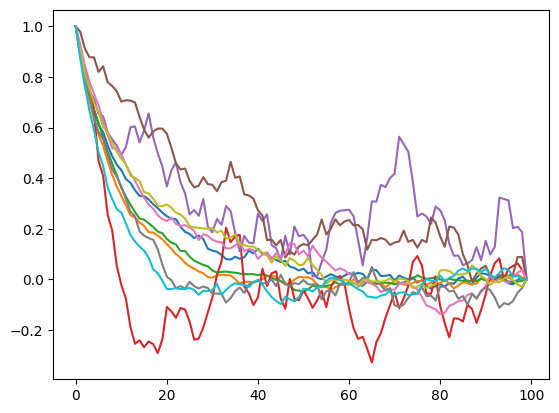

In [6]:
plt.plot(sampies[10:20].T)

In [7]:
import jax
import jax.numpy as jnp

@jax.jit
def get_expected_landscape_mtranstion(landscape, transition_matrices):
    """
    Calculates the expected fitness landscape after independent mutations.
    
    Args:
        landscape: An N-dimensional JAX array of shape (K, K, ..., K).
                   Contains the raw fitness values.
        transition_matrices: A JAX array of shape (N, K, K).
                             transition_matrices[i] is the KxK mutation 
                             matrix for the i-th dimension (gene).
                             
    Returns:
        The expected fitness landscape of the same shape (K, K, ..., K).
    """
    N = landscape.ndim
    x = landscape
    
    # Apply each gene's specific mutation matrix to its corresponding dimension
    for i in range(N):
        # Extract the K x K mutation matrix for this specific dimension
        T = transition_matrices[i]
        
        # Multiply T along the i-th axis of the landscape
        x = jnp.tensordot(T, x, axes=([1], [i]))
        
        # tensordot moves the operated axis to the front (index 0), 
        # so we move it back to its original position 'i'
        x = jnp.moveaxis(x, 0, i)
        
    return x
    
@jax.jit
def get_expected_landscape(landscape, transition_matrix):
    N = landscape.ndim
    x = landscape
    T = transition_matrix
    # Apply each gene's specific mutation matrix to its corresponding dimension
    for i in range(N):
        # Extract the K x K mutation matrix for this specific dimension
        
        # Multiply T along the i-th axis of the landscape
        x = jnp.tensordot(T, x, axes=([1], [i]))
        
        # tensordot moves the operated axis to the front (index 0), 
        # so we move it back to its original position 'i'
        x = jnp.moveaxis(x, 0, i)
        
    return x

get_expected_landscape(jnp.ones((2, 2, 2)), jnp.array([[0,1],[1,0]]) )

Array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]], dtype=float64)

In [8]:
import jax
import jax.numpy as jnp
with open('landscape_arrays/GB1_landscape_array.pkl', 'rb') as f:
    GB1 = pickle.load(f)

with open('landscape_arrays/E3_landscape_array.pkl', 'rb') as f:
    ParD3 = pickle.load(f)

with open('landscape_arrays/TEV_landscape_array.pkl', 'rb') as f:
    TEV = pickle.load(f)

with open('landscape_arrays/TrpB_landscape_array.pkl', 'rb') as f:
    TrpB = pickle.load(f)

empirical_landscapes = [GB1, TrpB, TEV, ParD3]
land_names = ['GB1', 'TrpB', 'TEV', 'ParD3']
@jax.jit
def get_dirichlet_energy(f, T):
    """
    Computes the normalized Dirichlet energy (ruggedness) of a landscape.
    
    Args:
        f: N-dimensional JAX array of shape (A, A, ..., A) representing fitness.
        T: (A, A) mutation transition matrix.
    """
    N = f.ndim
    A = f.shape[0]
    
    # 1. Define the base Laplacian for a single dimension
    # Assuming T is a standard transition matrix where rows sum to 1
    L = jnp.eye(A) - T
    
    # 2. Apply the full Laplacian (Kronecker sum) to the landscape
    delta_f = jnp.zeros_like(f)
    for i in range(N):
        # Apply L to the i-th dimension
        term = jnp.tensordot(L, f, axes=([1], [i]))
        term = jnp.moveaxis(term, 0, i)
        # Add instead of multiply!
        delta_f += term 
        
    # 3. Compute f^T \Delta f (Numerator)
    # This is the raw Dirichlet energy: sum(f * \Delta f)
    dirichlet_raw = jnp.sum(f * delta_f)
    
    # 4. Compute f^T f - b_0 (Denominator)
    # b_0 is the energy of the flat landscape (mean component)
    f_mean = jnp.mean(f)
    b_0 = (A ** N) * (f_mean ** 2)
    f_squared_sum = jnp.sum(f ** 2)
    denominator = f_squared_sum - b_0
    
    # 5. Final normalized metric (rho_Delta)
    # Dividing by N (the degree/dimension scaler 'd' in your formula)
    rho_delta = (1.0 / N) * (dirichlet_raw / denominator)
    
    return rho_delta


landy = jnp.ones((2, 2, 2))*0
landy = landy.at[0, 0, 0].add(1.1)
landy = landy +0
get_dirichlet_energy(landy, jnp.array([[0.0,1.0],[1.0,0.0]]) )

/tmp/ipykernel_21981/1923481270.py:4: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  GB1 = pickle.load(f)
/tmp/ipykernel_21981/1923481270.py:7: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  ParD3 = pickle.load(f)


Array(1.14285714, dtype=float64)

In [28]:
import jax
import jax.numpy as jnp

@jax.jit
def get_custom_spectra(f, T):
    N = f.ndim
    A = f.shape[0]
    
    # FIX 1: Diagonalize the Laplacian (L), not T.
    # This ensures the eigenvalue 0 (the flat mean) is strictly at index 0.
    L = jnp.eye(A) - T
    base_evals, V = jnp.linalg.eigh(L)
    
    # Transformation matrix (transpose of orthogonal eigenvectors)
    basis_matrix = V.T 
    
    # 1. The Custom Fast Transform
    spectrum = f
    for i in range(N):
        spectrum = jnp.tensordot(basis_matrix, spectrum, axes=([1], [i]))
        spectrum = jnp.moveaxis(spectrum, 0, i)
        
    # Raw squared coefficients
    squared_coeffs = spectrum ** 2
    
    # FIX 2: Generate the N-dimensional eigenvalues to compute exact Dirichlet Energy
    # Kronecker sum of eigenvalues
    full_evals = base_evals.copy()
    for _ in range(N - 1):
        full_evals = full_evals[..., None] + base_evals
        
    # Energy per coordinate = Eigenvalue * Coefficient^2
    dirichlet_components = full_evals * squared_coeffs

    # 2. Group by epistatic layers (interaction order)
    # Now it is safe to assume index 0 is the unmutated state
    is_mutated = jnp.array([0] + [1] * (A - 1))
    layer_grid = is_mutated.copy()
    for _ in range(N - 1):
        layer_grid = layer_grid[..., None] + is_mutated
        
    amplitude_spectrum = jnp.zeros(N + 1)
    energy_spectrum = jnp.zeros(N + 1)
    
    for order in range(N + 1):
        mask = (layer_grid == order)
        # Power spectrum (variance breakdown)
        amplitude_layer = jnp.sum(jnp.where(mask, squared_coeffs, 0.0))
        amplitude_spectrum = amplitude_spectrum.at[order].set(amplitude_layer)
        
        # Dirichlet energy breakdown
        energy_layer = jnp.sum(jnp.where(mask, dirichlet_components, 0.0))
        energy_spectrum = energy_spectrum.at[order].set(energy_layer)
        
    return amplitude_spectrum, energy_spectrum

@jax.jit
def get_generalized_spectral_distribution(f, T):
    N = f.ndim
    A = f.shape[0]
    
    L = jnp.eye(A) - T
    base_evals, V = jnp.linalg.eigh(L)
    
    # 1. Transform to the custom eigenbasis
    basis_matrix = V.T 
    spectrum = f
    for i in range(N):
        spectrum = jnp.tensordot(basis_matrix, spectrum, axes=([1], [i]))
        spectrum = jnp.moveaxis(spectrum, 0, i)
    
    # 2. Compute the exact eigenvalue for every single coordinate in the tensor
    # These represent the true "energy levels" of the landscape
    full_evals = base_evals.copy()
    for _ in range(N - 1):
        full_evals = full_evals[..., None] + base_evals
    
    # 3. Instead of N layers, let's look at the unique energy levels present
    # This captures the "orders" defined by your mutation matrix T
    flat_evals = full_evals.flatten()
    flat_weights = (spectrum ** 2).flatten()
    
    # We round slightly to handle floating point precision when grouping
    unique_energies, inverse_indices = jnp.unique(jnp.round(flat_evals, decimals=5), return_inverse=True)
    
    # Sum the variance (amplitude) for each unique energy level
    amplitude_per_level = jnp.zeros_like(unique_energies)
    amplitude_per_level = amplitude_per_level.at[inverse_indices].add(flat_weights)
    
    return unique_energies, amplitude_per_level

In [9]:
with open("plot_data/true_rho.pkl", "rb") as f:
    true_rho = pickle.load(f)

In [10]:
land_names

['GB1', 'TrpB', 'TEV', 'ParD3']

In [11]:
np.array(true_rho)*20/19

array([0.59757433, 0.60176358, 0.94421099, 0.42257886])

In [13]:
get_mean_spectrum_frequency(TEV, remove_constant= True) * 20/19

np.float64(0.9442109799627051)

In [14]:
norm_20_mat = jnp.ones((20, 20)) - jnp.eye(20)
norm_20_mat = norm_20_mat / norm_20_mat.sum(axis=1, keepdims=True)


In [15]:
get_dirichlet_energy(TEV,norm_20_mat)

Array(0.94421098, dtype=float64)

In [29]:
amp_spec = get_custom_spectra(TEV, norm_20_mat)

amp_spec_2 = get_generalized_spectral_distribution(TEV, norm_20_mat)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape float64[160000]
The error arose for the first argument of jnp.unique(). To make jnp.unique() compatible with JIT and other transforms, you can specify a concrete value for the size argument, which will determine the output size.
The error occurred while tracing the function get_generalized_spectral_distribution at /tmp/ipykernel_21981/1860921128.py:57 for jit. This concrete value was not available in Python because it depends on the value of the argument T.

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [23]:
amp_spec


(Array([8.49305465e+04, 3.76357507e+01, 4.16957464e+01, 1.37833643e+02,
        5.93839195e+02], dtype=float64),
 Array([-6.78382185e-11,  3.96165797e+01,  8.77805187e+01,  4.35264137e+02,
         2.50037556e+03], dtype=float64))

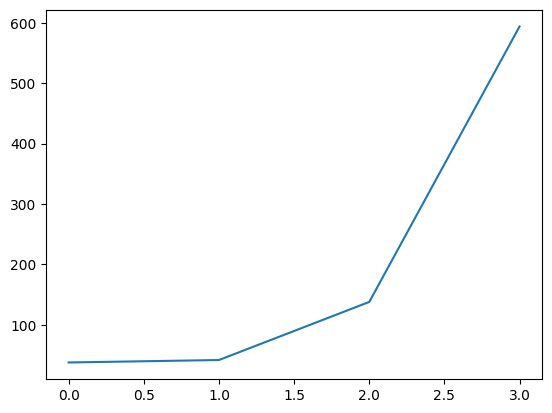

In [27]:
plt.plot(amp_spec[0][1:])